<a href="https://colab.research.google.com/github/aminmoosavi/PyTorch/blob/main/PyTorch_06_Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PyTorch Days 6–10: Building a Transformer-Based GPT Language Model**

**In this notebook, we will learn how to implement a GPT-style language model based on the Transformer architecture using PyTorch.**

**Our goal is to build a smaller version of the GPT-2 architecture that preserves the key components of the original model while being computationally efficient enough to train and experiment with on a personal computer.**

Throughout this notebook, we will implement the main components of a GPT model from scratch, including:

1. Token embeddings
2. Transformer blocks
3. Multi-head self-attention
4. Layer normalization
5. Feed-forward (MLP) layers
6. The unembedding layer that produces vocabulary logits

By the end of this notebook, we will have a working miniature GPT model capable of learning language patterns from data and generating text.*


In [ ]:
try:
    import datasets
except ImportError:
    !pip install datasets
    import datasets

In [ ]:
try:
    import transformers
except ImportError:
    %pip install transformers
    import transformers

In [ ]:
import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from tqdm.notebook import tqdm

# Checking for GPU Availability

**This notebook is being run on a Mac with Apple Silicon. PyTorch can therefore use Apple's Metal Performance Shaders (MPS) backend to accelerate computations on the GPU.**

Before training the model, it is good practice to check whether GPU acceleration is available and select the appropriate device:

* If an Apple Silicon GPU is available, use the **MPS** backend.
* Otherwise, if an NVIDIA GPU with CUDA support is available, use **CUDA**.
* If neither is available, fall back to the **CPU**.

Using a GPU can significantly reduce the training time of Transformer models compared to running exclusively on the CPU.

In [ ]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple Silicon GPU (MPS)")
else:
    device = torch.device("cpu")
    print("MPS not available. Using CPU.")

Using Apple Silicon GPU (MPS)


# Dataset

**In this notebook, we use the TinyStories dataset to train our miniature GPT model.**

TinyStories is a collection of short, simple stories written in natural language. Its relatively small vocabulary and straightforward sentence structure make it an excellent dataset for learning how Transformer-based language models are trained.

The dataset provides enough linguistic diversity for the model to learn grammar, syntax, and basic semantic relationships while remaining computationally manageable for training on a personal computer.

In [ ]:
train_data = datasets.load_dataset("roneneldan/TinyStories", split="train")
test_data = datasets.load_dataset("roneneldan/TinyStories", split="validation")
print('------------------------------------------------------------')
print('Training data:\n',train_data)
print('Testing data:\n',test_data)
print('------------------------------------------------------------')
print('An example of training data:\n',train_data[0])
print('An example of testing data:\n',test_data[0])

------------------------------------------------------------
Training data:
 Dataset({
    features: ['text'],
    num_rows: 2119719
})
Testing data:
 Dataset({
    features: ['text'],
    num_rows: 21990
})
------------------------------------------------------------
An example of training data:
 {'text': 'One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.\n\nLily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."\n\nTogether, they shared the needle and sewed the button on Lily\'s shirt. It was not difficult for them because they were sharing and helping each other. After they finished, Lily thanked her mom for sharing the needle and fixing her shirt. They both felt happy because they had shared and w

# Tokenization

**For tokenization, we use the GPT-2 tokenizer.**

Tokenization is the process of converting raw text into smaller units called **tokens** that can be processed by a neural network. Each unique token in the vocabulary is assigned a unique integer identifier called a **token ID**.

For example, a sentence is first divided into tokens:

```text
"the car is shiny."
        ↓
["the", " car", " is", " shiny", "."]
        ↓
[262, 1097, 318, 22441, 13]
```

The tokenizer performs two main tasks:

1. **Token splitting:**  
   Breaks the input text into a sequence of tokens using predefined rules. GPT-2 uses a byte-pair encoding (BPE) tokenizer, which can represent common words as single tokens while splitting rare words into smaller subword units.

2. **Token-to-integer mapping:**  
   Assigns each unique token an integer index from the vocabulary.

The resulting sequence of token IDs is used as the input to the embedding layer, where each token ID is converted into a continuous vector representation that the Transformer model can process.

In [ ]:
%%time
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("gpt2")

def tokenize_dataset(dataset):
    token_ids = []

    for story in tqdm(dataset, desc="Tokenizing"):
        # Add a blank line before every story
        text = "\n\n" + story["text"]

        ids = tokenizer.encode(
            text,
            add_special_tokens=False
        )

        token_ids.extend(ids)

    return torch.tensor(token_ids, dtype=torch.int64)

train_tokens = tokenize_dataset(train_data).to(device)
test_tokens = tokenize_dataset(test_data).to(device)

print(train_tokens.shape)
print(test_tokens.shape)
print(train_tokens.dtype)

Tokenizing:   0%|          | 0/2119719 [00:00<?, ?it/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1108 > 1024). Running this sequence through the model will result in indexing errors


Tokenizing:   0%|          | 0/21990 [00:00<?, ?it/s]

torch.Size([476111725])
torch.Size([4787908])
torch.int64
CPU times: user 7min 4s, sys: 7.42 s, total: 7min 11s
Wall time: 7min 18s


**Notice that the number of tokens is much larger than the number of words in the dataset**

In [ ]:
# Looking at some data
token_ids = test_tokens[0:20] #<- first 20 tokens of the first story
tokens = tokenizer.convert_ids_to_tokens(token_ids)

for token_id, token in zip(token_ids, tokens):
    print(f"story token ids = {token_id:6d} , story tokes = {token.replace("Ġ", " ").replace("Ċ", "\n")}")

story token ids =    198 , story tokes = 

story token ids =    198 , story tokes = 

story token ids =  32565 , story tokes = Spot
story token ids =     13 , story tokes = .
story token ids =  15899 , story tokes =  Spot
story token ids =   2497 , story tokes =  saw
story token ids =    262 , story tokes =  the
story token ids =  22441 , story tokes =  shiny
story token ids =   1097 , story tokes =  car
story token ids =    290 , story tokes =  and
story token ids =    531 , story tokes =  said
story token ids =     11 , story tokes = ,
story token ids =    366 , story tokes =  "
story token ids =  22017 , story tokes = Wow
story token ids =     11 , story tokes = ,
story token ids =  21168 , story tokes =  Kitty
story token ids =     11 , story tokes = ,
story token ids =    534 , story tokes =  your
story token ids =   1097 , story tokes =  car
story token ids =    318 , story tokes =  is


### Reshaping the Training Data for the Embedding Layer

**Before passing the training data to the embedding layer, we need to reshape the token IDs into the format expected by the Transformer model.**

The input data is organized into batches, where each batch contains multiple sequences of tokens. The resulting tensor should have the following shape:

```text
(N_batches, batch_size, context_size)
```

For this implementation:

* `N_batches` — the total number of batches in the dataset.
* `batch_size = 64` — the number of sequences processed together in one batch.
* `context_size = 64` — the number of tokens in each input sequence.

Each element of this tensor is an integer token ID produced by the tokenizer:

```text
Token IDs

[
  [token_1, token_2, ..., token_64],
  [token_1, token_2, ..., token_64],
  ...
]

Shape: (N_batches, 64, 64)
```

During model development, we use this reshaped data to test and verify the individual components of the GPT model, such as the embedding layer, attention mechanism, and Transformer blocks.

For the actual training loop, we will use a more efficient data-loading approach that dynamically creates batches during training rather than storing all batches explicitly in memory.

In [ ]:
batch_size = 64
context_size = 64

n_test = (test_tokens.shape[0]//(batch_size * context_size)) * (batch_size * context_size)
n_train = (train_tokens.shape[0]//(batch_size * context_size)) * (batch_size * context_size)

train_set = train_tokens[:n_train]
test_set = test_tokens[:n_test]


N_batches = n_train // (batch_size * context_size)
print(f"Number of batches={N_batches}")
train_set_r = train_set.reshape(N_batches , batch_size , context_size)
train_set_r.shape
vocab_size = train_set_r.max()
print(f"Vocab size= {vocab_size}")
print(f"Shape of the training set={train_set_r.shape}")

Number of batches=116238
Vocab size= 50255
Shape of the training set=torch.Size([116238, 64, 64])


### Sending the Data to the Device

**Before training the model, the input data must be transferred to the appropriate computing device.**

In PyTorch, tensors can be stored and processed on different devices, such as:

* **CPU** — the default processing unit.
* **GPU** — used to accelerate large matrix operations during model training.
* **Apple Silicon GPU (MPS)** — Apple's Metal Performance Shaders backend for GPU acceleration on Mac computers.

To take advantage of hardware acceleration, all input tensors must be moved to the same device as the model. This ensures that the data and model parameters are located in the same memory space and can be used together during forward and backward passes.

The typical workflow is:

```text
Raw Data
    │
    ▼
Tokenized Data (CPU)
    │
    ▼
Move tensors to device
    │
    ▼
GPU / MPS / CPU
    │
    ▼
Model Training
```

In PyTorch, this is done using the `.to(device)` method:

```python
data = data.to(device)
model = model.to(device)
```

Using the appropriate device can significantly improve training speed, especially for Transformer models that rely heavily on matrix multiplications.

In [ ]:
train_set_r = train_set_r.to(device)

# Creating the model

### Data Configuration

**The `DataConfig` class stores the parameters that define how the training data is prepared and presented to the model.**

The configuration controls the size of the dataset batches, the vocabulary representation, and the length of the input sequences used by the Transformer.

The parameters are:

* `N_batches`  
  The number of batches used during training. It determines how many groups of examples are processed.

* `batch_size`  
  The number of training examples contained in each batch. Larger batch sizes can improve computational efficiency but require more memory.

* `vocab_size`  
  The number of unique tokens in the tokenizer vocabulary. This determines the size of the embedding matrix and the output dimension of the unembedding layer.

* `context_size`  
  The maximum number of tokens the model can process at once. This defines the length of the context window and determines the size of the attention matrix.

  

In [ ]:
@dataclass
class DataConfig:
    N_batches: int
    batch_size: int
    vocab_size: int
    context_size: int

### Model Configuration

**The `ModelConfig` class defines the architecture and hyperparameters of the Transformer-based GPT model.**

These parameters determine the size of the model, the structure of the Transformer blocks, and the behavior of the training process.

The parameters are:

* `context_size`  
  The maximum sequence length that the model can attend to. It defines the size of the context window.

* `embed_dim`  
  The dimensionality of the token embedding vectors. Each token is represented by a vector of this size.

* `init_std`  
  The standard deviation used for initializing the model parameters. Proper initialization helps stabilize training.

* `eps`  
  A small numerical constant used in layer normalization to prevent division by zero.

* `N_heads`  
  The number of attention heads in the multi-head self-attention mechanism. Multiple heads allow the model to learn different types of relationships between tokens.

* `attn_dim`  
  The dimensionality of the attention space used for the query, key, and value representations.

* `dropout`  
  The probability used for dropout regularization, which helps reduce overfitting during training.

* `MLP_hidden_size`  
  The hidden dimension of the feed-forward neural network (MLP) inside each Transformer block. This is typically larger than the embedding dimension to increase the model's expressive power.

* `N_layers`  
  The number of Transformer blocks stacked sequentially in the model. Increasing this value increases the depth and capacity of the model.

In [ ]:
@dataclass
class ModelConfig:
    context_size: int
    embed_dim: int
    init_std: float
    eps: float
    N_heads: int
    attn_dim: int
    dropout: float
    MLP_hidden_size: float
    N_layers: int

### Setting the stage

In [ ]:
d_cfg = DataConfig(N_batches =  N_batches,
                   batch_size = batch_size,
                   vocab_size = vocab_size.item(),
                   context_size =context_size
                  )

m_cfg = ModelConfig(context_size =context_size,
                    embed_dim=512,
                    init_std=0.02,
                    eps=1e-5,
                    N_heads = 4,
                    attn_dim = 128,
                    dropout = 0.1,
                    MLP_hidden_size = 1024,
                    N_layers = 4
                   )

print(m_cfg)
print(d_cfg)

ModelConfig(context_size=64, embed_dim=512, init_std=0.02, eps=1e-05, N_heads=4, attn_dim=128, dropout=0.1, MLP_hidden_size=1024, N_layers=4)
DataConfig(N_batches=116238, batch_size=64, vocab_size=50255, context_size=64)


### The Embedding Layer

**The embedding layer assigns a learnable vector to every unique token in the vocabulary. Each token is represented by a vector in a high-dimensional embedding space whose dimension is given by `m_cfg.embed_dim`.**

If the vocabulary contains $V$ unique tokens, the embedding layer consists of an embedding matrix

* $\mathbf{W}_{\rm embedding} \in \mathbb{R}^{V \times d_{\rm embed}}$

where

* $V$ is the vocabulary size.
* $d_{\rm embed} =$ `m_cfg.embed_dim` is the embedding dimension.

Each row of the embedding matrix corresponds to the embedding vector of one vocabulary token. When a token with index $i$ is encountered, its embedding vector is obtained by simply looking up the $i^{\rm th}$ row of the embedding matrix:

* $\mathbf{x}_i = \mathbf{W}_{\rm embedding}[i]$

The embedding vectors are initialized randomly and are learned during training through backpropagation. As training progresses, tokens that appear in similar linguistic contexts tend to develop similar vector representations, allowing the model to capture semantic and syntactic relationships between words.

In [ ]:
class Embedding(nn.Module):
    def __init__(self, m_cfg:ModelConfig , d_cfg:DataConfig):
        super().__init__()
        vocab_size = d_cfg.vocab_size
        embed_dim = m_cfg.embed_dim
        context_size = m_cfg.context_size

        # Token embedding
        self.token_embedding = nn.Parameter(
            torch.empty(vocab_size, embed_dim)
        )
        # Positional embedding
        self.position_embedding = nn.Parameter(
            torch.empty(context_size, embed_dim)
        )

        # Initialization
        nn.init.normal_(self.token_embedding, mean=0.0, std=m_cfg.init_std)
        nn.init.normal_(self.position_embedding, mean=0.0, std=m_cfg.init_std)

    def forward(self, input_ids):

        position_ids = torch.arange(context_size, device=input_ids.device)

        x = self.token_embedding[input_ids] + self.position_embedding[position_ids]

        return x

**Taking a look at the embedding layer**

In [ ]:
model_embed = Embedding(m_cfg , d_cfg)
model_embed.to(device)
model_embed.eval()
X=train_set_r[0,:,:].squeeze()
print(f"Input is on device:{X.device}")
model_embed.eval()
with torch.inference_mode():
    Y_embed = model_embed(X)
print(f"Shape of the embedding layer output= {Y_embed.shape}")
model_embed.state_dict()
print(f"Output is on device:{Y_embed.device}")

Input is on device:mps:0
torch.Size([64, 10])
Shape of the embedding layer output= torch.Size([64, 10, 512])
Output is on device:mps:0


### The Normalization Layer

**The normalization layer standardizes each vector in the embedding space so that its components have zero mean and unit variance. The normalized vector is then scaled and shifted using two learnable parameters, $\gamma$ and $\beta$, allowing the network to recover any desired mean and variance if needed.**

* $\mathbf{x}_{\rm normalized} =
\gamma \,
\frac{\mathbf{x}-{\rm mean}(\mathbf{x})}
{\sqrt{{\rm var}(\mathbf{x})+\epsilon}}
+\beta$

where:

* ${\rm mean}(\mathbf{x})$ is the mean of the components of the embedding vector.
* ${\rm var}(\mathbf{x})$ is the variance of the components.
* $\epsilon$ is a small positive constant added for numerical stability to prevent division by zero.
* $\gamma$ and $\beta$ are learnable parameters that scale and shift the normalized vector.

Normalization improves the stability of training by keeping the activations at a consistent scale, which helps gradients propagate more effectively through deep networks.

In [ ]:
class Normalize(nn.Module):
    def __init__(self, m_cfg:ModelConfig):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(m_cfg.embed_dim))
        self.beta = nn.Parameter(torch.zeros(m_cfg.embed_dim))
        self.eps = m_cfg.eps

    def forward(self, x: torch.Tensor):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)

        x = (x - mean) / torch.sqrt(var + self.eps)

        return self.gamma * x + self.beta

**Looking at the Normalization layer**

In [ ]:
model_norm = Normalize(m_cfg)
model_norm.to(device)
model_norm.eval()
with torch.inference_mode():
    Y_norm = model_norm(Y_embed)

print(f"Normalization layer output shape is {Y_norm.shape}")
print(f"Output is on device:{Y_norm.device}")
print(list(model_norm.state_dict()))


Normalization layer output shape is torch.Size([64, 64, 512])
Output is on device:mps:0
['gamma', 'beta']


### The Attention Layer

**This is the core component of the Transformer architecture.**

1. **Projecting the embeddings into the attention space**

   The attention layer takes the token representations in the **embedding space** and applies three independent linear transformations that map them into a lower-dimensional **attention space**. These transformations produce the **query**, **key**, and **value** vectors.

   For the embedding vector at position $i$ in the context window, $\mathbf{x}_i$,

   * $\mathbf{q}_i = \mathbf{W}_{\rm query}\,\mathbf{x}_i + \mathbf{b}_{\rm query}$
   * $\mathbf{k}_i = \mathbf{W}_{\rm key}\,\mathbf{x}_i + \mathbf{b}_{\rm key}$
   * $\mathbf{v}_i = \mathbf{W}_{\rm value}\,\mathbf{x}_i + \mathbf{b}_{\rm value}$

2. **Computing the attention scores**

   For every pair of positions $(i,j)$ in the input sequence, the attention score is computed by taking the dot product of the query vector at position $i$ and the key vector at position $j$, and then scaling the result by the square root of the attention-space dimension $d$:

   * $S_{i,j} = \dfrac{\mathbf{q}_i \cdot \mathbf{k}_j}{\sqrt{d}}$

   The matrix $S$ contains the attention scores between every pair of tokens in the sequence.

   In a **causal (autoregressive) Transformer**, tokens are not allowed to attend to future positions. To enforce this constraint, the entries in the upper triangular part of the score matrix are replaced with $-\infty$. After applying the softmax function, these entries become zero, ensuring that each token attends only to itself and to previous tokens.

   The dot products between queries and keys allow the model to capture interactions between different tokens in the context. As a result, the prediction of the next token depends not only on the individual token representations but also on the relationships among them.

3. **Applying the softmax**

   The attention scores are converted into normalized attention weights using the softmax function. During training, dropout is often applied to these weights as a regularization technique to reduce overfitting.

   * $A_{i,j} = \dfrac{e^{S_{i,j}}}{\sum_j e^{S_{i,j}}}$

4. **Computing the output vectors**

   The output vector at each position is a weighted sum of the value vectors, where the weights are given by the attention matrix:

   * $\mathbf{z}_i = \sum_j A_{i,j}\mathbf{v}_j$

5. **Multiple attention heads**

   In practice, the Transformer uses multiple attention heads. Each head has its own query, key, and value projection matrices, producing an output vector $\mathbf{z}_{i,h}$ for every position $i$ and head $h$.

6. **Concatenating the heads**

   The outputs from all attention heads are concatenated along the feature dimension to form a single vector for each position:

   * $\mathbf{Z}_i = \left[\mathbf{z}_{i,1};\,\mathbf{z}_{i,2};\,\cdots;\,\mathbf{z}_{i,H}\right]$

   where $H$ is the number of attention heads. The resulting vector has dimension $H \times d$.

7. **Projecting back to the embedding space**

   Finally, the concatenated vector is mapped back to the original embedding space using another linear transformation:

   * ${\rm Output}_i = \mathbf{W}_{\rm output}\,\mathbf{Z}_i + \mathbf{b}_{\rm output}$

   This output is then passed to the next components of the Transformer block (typically a residual connection, layer normalization, and a feed-forward network).

In [ ]:
class Attention(nn.Module):
    def __init__(self, m_cfg:ModelConfig):
        super().__init__()


        self.W_keyes = nn.Parameter(
            torch.empty((m_cfg.N_heads, m_cfg.attn_dim, m_cfg.embed_dim))
        ) #<- To map the embedded model vectors to attention keyes

        self.b_keyes = nn.Parameter(
            torch.zeros((m_cfg.N_heads, m_cfg.attn_dim))
        ) #<- bias for keyes

        self.W_queries = nn.Parameter(
            torch.empty((m_cfg.N_heads, m_cfg.attn_dim, m_cfg.embed_dim))
        ) #<- To map the embedded model vectors to attention queries

        self.b_queries = nn.Parameter(
            torch.zeros((m_cfg.N_heads, m_cfg.attn_dim))
        ) #<- bias for queries

        self.W_values = nn.Parameter(
            torch.empty((m_cfg.N_heads, m_cfg.attn_dim, m_cfg.embed_dim))
        ) #<- To map the embedded model vectors to attention values

        self.b_values = nn.Parameter(
            torch.zeros((m_cfg.N_heads, m_cfg.attn_dim))
        ) #<- bias for values

        self.W_output = nn.Parameter(
            torch.empty((m_cfg.N_heads * m_cfg.attn_dim, m_cfg.embed_dim))
        ) #<- To map from attention space back to embedding space

        self.b_output = nn.Parameter(
            torch.zeros((m_cfg.embed_dim))
        ) #<- output bias

        # initializing with standard Gaussian random numbers
        nn.init.normal_(self.W_queries, std=m_cfg.init_std)
        nn.init.normal_(self.W_keyes, std=m_cfg.init_std)
        nn.init.normal_(self.W_values, std=m_cfg.init_std)
        nn.init.normal_(self.W_output, std=m_cfg.init_std)


        self.register_buffer("neg_inf",
                             torch.tensor(float("-inf"),
                             dtype=torch.float32)
                            ) #<- will be used later for causal masking

        self.register_buffer("mask",
                            torch.triu(
                                torch.ones(size=(m_cfg.context_size , m_cfg.context_size) , device=device ),
                                diagonal=1).bool()
                            ) #<- The causal mask

        self.m_cfg = m_cfg #<- owning the cfg info
        self.attention_dropout = nn.Dropout(m_cfg.dropout)

    def forward(self, x):

        # Mapping vectors from the embedding space to attention space.
        ## for the following we can also use torch.einsum()
        x_k = torch.tensordot(x, self.W_keyes, dims=([-1], [-1])) + self.b_keyes
        x_q = torch.tensordot(x, self.W_queries,  dims=([-1], [-1])) + self.b_queries
        x_v = torch.tensordot(x, self.W_values, dims=([-1], [-1])) + self.b_values
        # print(f"Shape of x_v is {x_v.shape}")


        attn_scores = torch.einsum(
            'bqha,bkha -> bhqk',
            x_q , x_k) #<- contract on the attention dimension (dot product of queries and keyes)

        attn_scores /= self.m_cfg.attn_dim**0.5 #<- Normalizing with square root of attention space dimension

        q = x.shape[1]
        attn_scores = attn_scores.masked_fill_(
            self.mask[:q,:q],
            self.neg_inf
        ) #<- applying the causal mask
        # print(f"Shape of attention scores is {attn_scores.shape}")

        attn_probs = attn_scores.softmax(dim = -1) #<- scores to probabilities so that sum of each row adds up to one
        attn_probs = self.attention_dropout(attn_probs)

        V = torch.einsum(
            'bhqv,bvha->bqha',
            attn_probs , x_v
        )#<- computing the weighted values

        b, q, h, a = V.shape
        V = V.reshape(b, q, h * a) #<- Concatenating all the heads
        # print(f"Shape of wighted values is {V.shape}")

        output = torch.einsum(
            'ce,bvc->bve',
            self.W_output , V
        ) + self.b_output
        return output

**Looking at the Attention class**

In [ ]:
model_attn = Attention(m_cfg)
model_attn.to(device)
model_attn.eval()
print(f"Shape of the Keyes matrix = {model_attn.W_keyes.shape}")
print(f"Shape of the input matrix = {Y_norm.shape}")
with torch.inference_mode():
    output = model_attn(Y_norm[:,:,:])
print(f"Attention layer output's shape is {output.shape}")


Shape of the Keyes matrix = torch.Size([4, 128, 512])
Shape of the input matrix = torch.Size([64, 64, 512])
Attention layer output's shape is torch.Size([64, 64, 512])


### The MLP Layer

**The Multi-Layer Perceptron (MLP) provides a nonlinear transformation of each token representation. Unlike the attention layer, which allows different tokens to interact, the MLP processes each token independently.**

For an input token vector $\mathbf{x}_i$ in the embedding space, the MLP consists of two linear transformations separated by a nonlinear activation function:

* $\mathbf{h}_i = f\!\left(\mathbf{W}_1\mathbf{x}_i + \mathbf{b}_1\right)$
* $\mathbf{y}_i = \mathbf{W}_2\mathbf{h}_i + \mathbf{b}_2$

where

* $\mathbf{W}_1$ and $\mathbf{W}_2$ are learnable weight matrices.
* $\mathbf{b}_1$ and $\mathbf{b}_2$ are learnable bias vectors.
* $f(\cdot)$ is a nonlinear activation function (typically **GELU** in modern Transformers).

The hidden dimension of the MLP is typically several times larger than the embedding dimension, allowing the network to learn rich nonlinear representations before projecting back to the embedding space.

**The same MLP is applied independently to the token vector at every position in the input sequence.** Consequently, the MLP does **not** exchange information between different tokens; all interactions between tokens occur in the attention layer. Instead, the MLP increases the expressive power of the model by learning complex nonlinear transformations of each token representation.

In [ ]:
class MLP(nn.Module):
    def __init__(self, m_cfg):
        super().__init__()

        self.linear1 = nn.Linear(
            m_cfg.embed_dim,
            m_cfg.MLP_hidden_size
        )

        self.linear2 = nn.Linear(
            m_cfg.MLP_hidden_size,
            m_cfg.embed_dim
        )

        self.activation = nn.GELU()

    def forward(self, x):
        x = self.linear1(x)
        x = self.activation(x)
        x = self.linear2(x)
        return x

**Looking at the MLP layer**

In [ ]:
model_MLP = MLP(m_cfg)
model_MLP.to(device)
model_MLP.eval()
with torch.inference_mode():
    MLP_out = model_MLP(output)

print(list(model_MLP.state_dict()))
print(MLP_out.shape)

['linear1.weight', 'linear1.bias', 'linear2.weight', 'linear2.bias']
torch.Size([64, 64, 512])


### The Transformer Block

**We now have all the components needed to construct a Transformer block. The input to the first Transformer block is the sequence of token embeddings produced by the embedding layer. The output of each Transformer block is then passed as the input to the next block.**

A Transformer block consists of the following sequence of operations:

```
Input
  │
  ▼
Layer Normalization
  │
  ▼
Multi-Head Attention
  │
  ▼
Residual Connection
  │
  ▼
Layer Normalization
  │
  ▼
MLP (Feed-Forward Network, Tokenwise nonlinearity)
  │
  ▼
Residual Connection
  │
  ▼
Output
```

The attention layer enables communication between different tokens in the sequence, while the MLP applies a nonlinear transformation independently to each token. The residual connections preserve information from earlier layers and improve gradient flow during training, and the normalization layers help stabilize training by keeping the activations well-scaled.

The output of one Transformer block has the same dimension as its input, allowing multiple blocks to be stacked to build deep Transformer models.

In [ ]:
class TransformerBlock(nn.Module ):
    def __init__(self, m_cfg: ModelConfig):
        super().__init__()
        self.norm1 = Normalize(m_cfg)
        self.attn = Attention(m_cfg)
        self.norm2 = Normalize(m_cfg)
        self.mlp = MLP(m_cfg)
        self.m_cfg = m_cfg

    def forward(self , x):
        x = self.attn(self.norm1(x)) + x #<- adding the residual after attention
        x = self.mlp(self.norm2(x)) + x #<- adding the residual after MLP
        return x


**Looking at the transformer block**

In [ ]:
model_transformer = TransformerBlock(m_cfg)
model_transformer.to(device)
print( list( model_transformer.state_dict() ) )

model_transformer.eval()
with torch.inference_mode():
    transformer_output = model_transformer(Y_embed)

print(transformer_output.shape)

['norm1.gamma', 'norm1.beta', 'attn.W_keyes', 'attn.b_keyes', 'attn.W_queries', 'attn.b_queries', 'attn.W_values', 'attn.b_values', 'attn.W_output', 'attn.b_output', 'attn.neg_inf', 'attn.mask', 'norm2.gamma', 'norm2.beta', 'mlp.linear1.weight', 'mlp.linear1.bias', 'mlp.linear2.weight', 'mlp.linear2.bias']
torch.Size([64, 64, 512])


### The Unembedding Layer

**The unembedding layer is the final linear transformation of the Transformer. It maps the output vector of each token from the embedding space to a vector of logits whose dimension equals the vocabulary size.**

If the vocabulary contains $V$ unique tokens and the embedding dimension is $d_{\rm embed}$, the unembedding layer consists of a weight matrix and a bias vector:

* $\mathbf{W}_{\rm unembed} \in \mathbb{R}^{V \times d_{\rm embed}}$
* $\mathbf{b}_{\rm unembed} \in \mathbb{R}^{V}$

For the output vector of the Transformer at position $i$, $\mathbf{x}_i$, the corresponding logits are computed as

* $\mathbf{l}_i = \mathbf{W}_{\rm unembed}\mathbf{x}_i + \mathbf{b}_{\rm unembed}$

where $\mathbf{l}_i \in \mathbb{R}^{V}$ is a vector containing one logit for every token in the vocabulary.

The logits are then passed through a softmax function to produce a probability distribution over the vocabulary for each token position in the context:

* $P(\text{token}_i=j \mid \text{token}_1 ,\text{token}_2, \dots,\text{token}_{i-1} ) =
\dfrac{e^{l_{i,j}}}
{\sum_{k=1}^{V} e^{l_{i,k}}}$

The token with the highest probability (or one sampled from this distribution) is selected as the model's prediction for the next token.

In [ ]:
class Unembed(nn.Module):
    def __init__(self,m_cfg:ModelConfig , d_cfg:DataConfig):
        super().__init__()
        self.unembed = nn.Linear(in_features = m_cfg.embed_dim , out_features=d_cfg.vocab_size)

    def forward(self,x):
        return self.unembed(x)

**Looking at the Unembedding layer**

In [ ]:
model_unembed = Unembed(m_cfg , d_cfg)
model_unembed.to(device)

model_unembed.eval()
with torch.inference_mode():
    unembed_output = model_unembed(transformer_output)

print(unembed_output.shape)

torch.Size([64, 64, 50255])


### Putting Together a Miniature GPT Model

**We now have all the building blocks needed to construct a miniature GPT model. The model consists of the following components:**

1. **Embedding Layer**  
   Converts each input token into a learnable vector in the embedding space.

2. **Stack of \(N\) Transformer Blocks**  
   A sequence of identical Transformer blocks, each composed of:
   * Layer Normalization
   * Multi-Head Self-Attention
   * Residual Connection
   * Layer Normalization
   * MLP (Feed-Forward Network)
   * Residual Connection

3. **Final Layer Normalization**  
   Applies one last normalization to the output of the final Transformer block before the prediction stage.

4. **Unembedding Layer**  
   Maps the final token representations from the embedding space to a vector of logits, with one logit for each token in the vocabulary.

The overall architecture can be summarized as

```text
Input Tokens
      │
      ▼
Embedding Layer
      │
      ▼
Transformer Block
      │
      ▼
Transformer Block
      │
     ⋮
      │
      ▼
Transformer Block (N)
      │
      ▼
Final Layer Normalization
      │
      ▼
Unembedding Layer
      │
      ▼
Logits
      │
      ▼
Softmax
      │
      ▼
Probability Distribution over the Vocabulary
```

The token with the highest probability (or one sampled from the probability distribution) is selected as the model's prediction for the next token. During text generation, this predicted token is appended to the input sequence, and the process is repeated autoregressively to generate text one token at a time.


In [ ]:
class MiniatureGpt(nn.Module):
    def __init__(self , m_cfg:ModelConfig , d_cfg:DataConfig ):
        super().__init__()
        self.embed = Embedding(m_cfg , d_cfg)
        self.transformer_stack = nn.ModuleList([TransformerBlock(m_cfg) for _ in range(m_cfg.N_layers)])
        self.norm = Normalize(m_cfg)
        self.unembed = Unembed(m_cfg , d_cfg)

    def forward(self ,x):
        x = self.embed(x)
        for block in self.transformer_stack:
            x = block(x)
        x = self.norm(x)
        x = self.unembed(x)
        return x #<- these outputs are logits that must be passt to a softmax to get probability of tokens



**Looking at the MiniatureGpt model**

In [ ]:
minigpt_model = MiniatureGpt(m_cfg , d_cfg)
minigpt_model.to(device)

minigpt_model.eval()
with torch.inference_mode():
    minigpt_output = minigpt_model(X)

# print( '----Listing the model state dict:\n' , list( minigpt_model.state_dict() ) )
print(f"----Output shape: {minigpt_output.shape}")
print(f"----An exampel of the output logits:\n {minigpt_output[0,0,:]}")

----Output shape: torch.Size([64, 64, 50255])
----An exampel of the output logits:
 tensor([ 0.1048,  0.0647,  0.0584,  ...,  0.4678, -0.5555, -1.6847],
       device='mps:0')


# The Training Process

**Training is the process of optimizing the parameters of the GPT model so that it learns to predict the next token in a sequence.**

During training, the model receives a sequence of input tokens and learns to predict the token that follows each position in the sequence. The prediction error is measured using a loss function, and the model parameters are updated using backpropagation and gradient-based optimization.

The main steps in the training loop are:

```text
Input Tokens
      │
      ▼
Embedding Layer
      │
      ▼
Transformer Model
      │
      ▼
Vocabulary Logits
      │
      ▼
Cross-Entropy Loss
      │
      ▼
Backpropagation
      │
      ▼
Update Model Parameters
```

For each training iteration:

1. **Load a batch of tokenized sequences**

   A batch of input sequences with shape:

   ```text
   (batch_size, context_size)
   ```

   is provided to the model.

2. **Forward pass**

   The input tokens are passed through the embedding layer, Transformer blocks, normalization layer, and unembedding layer to produce logits for every position in the sequence.

3. **Calculate the loss**

   The predicted logits are compared with the actual next tokens using the cross-entropy loss function:

   * The model is rewarded for assigning high probability to the correct next token.
   * Incorrect predictions contribute to the loss.

4. **Backward pass**

   Gradients of the loss with respect to all model parameters are calculated using backpropagation.

5. **Parameter update**

   An optimizer (such as Adam or AdamW) updates the model parameters to reduce the loss.

The training process is repeated over many batches and epochs, allowing the model to gradually learn statistical patterns in the data, including grammar, token relationships, and higher-level language structures.

The goal is not to memorize the training data, but to learn a set of parameters that can generate and predict plausible sequences of tokens.

### Loss Function: Cross Entropy

**The cross-entropy loss function measures how well the model's predicted probability distribution matches the actual next token in the training data. It is the primary loss function used to train GPT-style language models.**

During training, the Transformer produces a vector of logits for every position in the input sequence. These logits are converted into probabilities using the softmax function:

* $P(y_i=j) = \frac{e^{l_{i,j}}}{\sum_k e^{l_{i,k}}}$

where:

* $l_{i,j}$ is the logit assigned to token $j$ at position $i$.
* $P(y_i=j)$ is the predicted probability that token $j$ is the correct next token.

The cross-entropy loss compares the predicted probability distribution with the true next token:

* $\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N} \log P(y_i)$

where:

* $N$ is the total number of prediction positions in the batch.
* $y_i$ is the correct next token at position $i$.
* $P(y_i)$ is the probability assigned by the model to the correct token.

The goal of training is to minimize this loss. A lower cross-entropy loss means that the model assigns higher probability to the correct next tokens.


In [ ]:
loss_fn = nn.CrossEntropyLoss()

### Adam Optimizer
Adam combines two ideas:

1. **Momentum (first moment):** keeps an exponential moving average of the gradients.
2. **Adaptive learning rates (second moment):** keeps an exponential moving average of the squared gradients.

For each parameter $w$, let the gradient at optimization step $t$ be

$$
g_t = \nabla_w L(w_t).
$$

The first moment estimate (momentum) is computed as

$$
m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t.
$$

The second moment estimate is

$$
v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2.
$$

Since both $m_t$ and $v_t$ are initialized to zero, they are biased toward zero during the initial optimization steps. Adam corrects this bias using

$$
\hat{m}_t = \frac{m_t}{1-\beta_1^t},
$$

$$
\hat{v}_t = \frac{v_t}{1-\beta_2^t}.
$$

Finally, the parameter update is

$$
w_{t+1}=w_t-\ell\frac{\hat{m}_t}{\sqrt{\hat{v}_t}+\epsilon},
$$

where

- $\ell$ is the learning rate,
- $\beta_1$ controls the decay rate of the first moment estimate,
- $\beta_2$ controls the decay rate of the second moment estimate, and
- $\epsilon$ is a small constant added for numerical stability.

In [ ]:
optimizer = torch.optim.AdamW(
    minigpt_model.parameters(),
    lr=1e-5,
    betas=(0.9, 0.95),
    weight_decay=0.01
)

### Preparing the Data: Creating $X_{\rm train}, y_{\rm train}$

**Before training the GPT model, the tokenized data must be organized into input sequences and corresponding target labels.**

In an autoregressive language model, the goal is to predict the **next token** given a sequence of previous tokens. Therefore, each training example consists of:

* **Input sequence (\(X\))**: a sequence of tokens with length equal to `context_size`.
* **Target sequence (\(y\))**: the same sequence shifted by one token, where each token is the prediction target for the corresponding input position.

For example, if the context size is 5:

```text
Input  (X):  The cat is sitting on
Target (y):  cat is sitting on the mat
```

The data preparation function performs the following steps:

1. Randomly selects starting positions from the tokenized text.
2. Extracts a sequence of tokens of length `context_size` to create the input batch.
3. Extracts the following tokens as the target labels.
4. Returns the input and target tensors to the training loop.

The resulting tensors have the shape:

```text
X: (batch_size, context_size)

y: (batch_size, context_size)
```

This function is called for every batch during the training loop, allowing the model to see different random sequences from the training data at each iteration.


In [ ]:
def get_batch(tokens, batch_size, context_size):

    # Pick random starting positions
    ix = torch.randint(
        len(tokens) - context_size - 1,
        (batch_size,)
    )

    X = torch.stack(
        [tokens[i:i+context_size] for i in ix]
    )

    y = torch.stack(
        [tokens[i+1:i+context_size+1] for i in ix]
    )

    return X, y


In [ ]:
X_train , y_train = get_batch(train_set, d_cfg.batch_size, d_cfg.context_size)
X_train , y_train = X_train.to(device) , y_train.to(device)
print(X_train.shape)
print(y_train.shape)

with torch.inference_mode():
    logits = minigpt_model(X_train)
b, p, v = logits.shape
loss = loss_fn(
    logits.view(b*p, v),
    y_train.view(b*p)
)
print(loss)


torch.Size([64, 64])
torch.Size([64, 64])
tensor(10.8935, device='mps:0')


In [ ]:
epochs = 1
losses = torch.zeros((epochs,d_cfg.N_batches), requires_grad=False , device = device)
minigpt_model.train()

for epoch in range(epochs):
    for batch in tqdm(range(d_cfg.N_batches) , desc = print(f"epoch {epoch+1}")):
        # Get the data for one batch
        X_train , y_train = get_batch(train_set, d_cfg.batch_size, d_cfg.context_size)
        X_train , y_train = X_train.to(device) , y_train.to(device)

        # Forward pass
        logits = minigpt_model(X_train)
        b, p, v = logits.shape

        # Compute the loss
        loss = loss_fn(
            logits.view(b*p, v),
            y_train.view(b*p)
        )

        # Set the gradient to zero
        optimizer.zero_grad()

        # Backprop (computing the gradient)
        loss.backward()

        # Gradient descent
        optimizer.step()

        # Saving the loss values for future visualization
        losses[epoch , batch] = loss.item() #<- Saving loss values

        # Looking at loss values for the first 1000 batches every 100 batch. We will plot them later.

        if (batch % 100 == 0 and batch<1001 ):
            if batch == 0:
                lossval = loss.item()
            else:
                lossval = losses[epoch,batch-100:batch].squeeze().mean()
            print(
                f"Epoch {epoch+1}/{epochs}, "
                f"Batch {batch}/{d_cfg.N_batches}, "
                f"Loss: {lossval:.4f}"
            )
        # Looking at loss values for the rest of batches every 1000 batch
        elif(batch % 1000 == 0 and batch>1001 ):
            lossval = losses[epoch,batch-1000:batch].squeeze().mean()
            print(
                f"Epoch {epoch+1}/{epochs}, "
                f"Batch {batch}/{d_cfg.N_batches}, "
                f"Loss: {lossval:.4f}"
            )


epoch 0


  0%|          | 0/116238 [00:00<?, ?it/s]

Epoch 1/1, Batch 0/116238, Loss: 10.8951
Epoch 1/1, Batch 100/116238, Loss: 9.3847
Epoch 1/1, Batch 200/116238, Loss: 8.2459
Epoch 1/1, Batch 300/116238, Loss: 7.4374
Epoch 1/1, Batch 400/116238, Loss: 6.7332
Epoch 1/1, Batch 500/116238, Loss: 6.1611
Epoch 1/1, Batch 600/116238, Loss: 5.7386
Epoch 1/1, Batch 700/116238, Loss: 6.5281
Epoch 1/1, Batch 800/116238, Loss: 7.7029
Epoch 1/1, Batch 900/116238, Loss: 7.3709
Epoch 1/1, Batch 1000/116238, Loss: 6.6796
Epoch 1/1, Batch 2000/116238, Loss: 4.9002
Epoch 1/1, Batch 3000/116238, Loss: 4.1238
Epoch 1/1, Batch 4000/116238, Loss: 3.7980
Epoch 1/1, Batch 5000/116238, Loss: 4.9321
Epoch 1/1, Batch 6000/116238, Loss: 4.5774
Epoch 1/1, Batch 7000/116238, Loss: 3.4475
Epoch 1/1, Batch 8000/116238, Loss: 3.3328
Epoch 1/1, Batch 9000/116238, Loss: 3.2482
Epoch 1/1, Batch 10000/116238, Loss: 3.1787
Epoch 1/1, Batch 11000/116238, Loss: 3.1234
Epoch 1/1, Batch 12000/116238, Loss: 3.0656
Epoch 1/1, Batch 13000/116238, Loss: 3.0207
Epoch 1/1, Batch 1

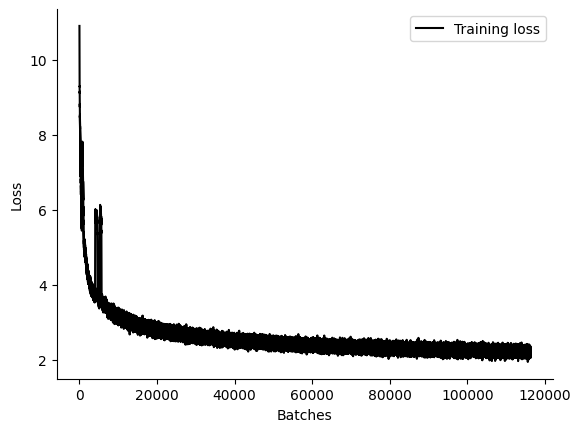

In [ ]:
# Casting the loss tensors into NumPy arrays
lossvals=losses.cpu().detach().numpy().squeeze()
# lossvals = np.mean(lossvals,axis=1)
# Plotting the loss functions
fig, ax = plt.subplots()
plt.plot(lossvals[:batch],'-',color='k',label = 'Training loss')
ax.set_xlabel('Batches')
ax.set_ylabel('Loss')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()
plt.show()

# Text Generation: Evaluating the Model

**We now test the ability of our trained GPT model to generate text.**

At this stage, we should keep our expectations realistic. This is a **miniature GPT model** trained for only a small number of training iterations (one epoch), using a relatively small dataset and model size.

### Text Generation Function

**The following function generates text using the GPT model in an autoregressive manner.**

The model generates new tokens one at a time by repeatedly predicting the next token based on the previously generated sequence.

The generation process follows these steps:

1. **Obtain the logits for the next token**

   The input token sequence is passed through the GPT model, which produces logits for every position in the sequence. We use the logits corresponding to the **last position**, since this represents the model's prediction for the next token.

2. **Apply temperature scaling**

   The logits are divided by a temperature parameter:

   * $\mathbf{l}_{\rm scaled} = {\mathbf{l}}/{T}$

   where $T$ is the temperature.

   The temperature controls the randomness of the generated text:

   * **Low temperature** ($T < 1$): produces more deterministic text by increasing the probability of the most likely tokens.
   * **High temperature** ($T > 1$): produces more diverse and stochastic text by flattening the probability distribution.

3. **Convert logits into probabilities**

   The scaled logits are passed through a softmax function to obtain a probability distribution over the vocabulary:

   * $P_i = \frac{e^{l_i}}{\sum_j e^{l_j}}$

4. **Sample the next token**

   A token is sampled from the resulting probability distribution using multinomial sampling. The sampled index corresponds to the newly generated token.

5. **Append the new token to the sequence**

   The newly generated token index is appended to the end of the current token sequence.

6. **Repeat autoregressively**

   The updated sequence, now including the newly generated token, is fed back into the GPT model to generate the next token. This process is repeated until the desired sequence length is reached.



In [ ]:
@torch.no_grad()
def generate(model, tokenizer, prompt, max_new_tokens=100, context_size=64, temperature=1.0):
    """
    This function generates new text by running the minigpt model

    prompt: list[int] or tensor of token ids
    returns: tensor containing prompt + generated tokens
    """

    model.eval()

    if not torch.is_tensor(prompt):
        tokens = torch.tensor(prompt, dtype=torch.long).unsqueeze(0)
    else:
        tokens = prompt.unsqueeze(0) if prompt.ndim == 1 else prompt

    device = next(model.parameters()).device
    tokens = tokens.to(device)

    # Left-pad with EOS tokens if prompt is shorter than context_size
    if tokens.shape[1] < context_size:
        pad_len = context_size - tokens.shape[1]
        pad = torch.full(
            (tokens.shape[0], pad_len),
            tokenizer.eos_token_id,
            dtype=tokens.dtype,
            device=device,
        )
        tokens = torch.cat([pad, tokens], dim=1)

    elif tokens.shape[1] > context_size:
        tokens = tokens[-context_size:]

    for _ in range(max_new_tokens):

        # logits: [1, T, vocab_size]
        with torch.inference_mode():
            if(tokens.shape[1]< context_size):
                logits = model(tokens)
            else:
                logits = model(tokens[:,-context_size:])

        # Only use the logits for the last position
        logits = logits[:, -1, :] / temperature

        # Convert to probabilities
        probs = F.softmax(logits, dim=-1)

        # Sample one token
        next_token = torch.multinomial(probs, num_samples=1)

        # Append it
        tokens = torch.cat([tokens, next_token], dim=1)

    return tokens.squeeze(0)

In [ ]:
# The prompt
prompt = test_set[0:m_cfg.context_size]
tokens = tokenizer.decode(prompt)
print(tokens)



Spot. Spot saw the shiny car and said, "Wow, Kitty, your car is so bright and clean!" Kitty smiled and replied, "Thank you, Spot. I polish it every day."

After playing with the car, Kitty and Spot felt thirsty. They found a small pond with clear water


In [ ]:
# generating new text

max_new_tokens =64
generated_ids = generate(
    minigpt_model,
    tokenizer,
    prompt,
    max_new_tokens=max_new_tokens,
    context_size = d_cfg.context_size,
    temperature=0.8,
)

# An untrained model
untrained_model = MiniatureGpt(m_cfg , d_cfg)
untrained_model.to(device)
generated_untrained = generate(
    untrained_model,
    tokenizer,
    prompt,
    max_new_tokens=max_new_tokens,
    context_size = d_cfg.context_size,
    temperature=0.8,
)



# print('Prompt text: \n', tokenizer.decode(generated_ids[0:d_cfg.context_size]),'\n')
print('----------------------------------------------------------------------------------------')
print('Generated text trained model: \n', tokenizer.decode(generated_ids[d_cfg.context_size:]),'\n')
print('----------------------------------------------------------------------------------------')
# print('True text: \n', tokenizer.decode(test_set[d_cfg.context_size:d_cfg.context_size+max_new_tokens]),'\n')
print('Generated text untrained model: \n', tokenizer.decode(generated_untrained[d_cfg.context_size:]),'\n')

----------------------------------------------------------------------------------------
Generated text trained model: 
 . They swam to the pond and picked more water from the fireplace. They decided to spray their clothes instead.

After dinner, they played with the water. They were happy and thirsty. Tim and Kim liked to drink juice. They wanted to look at the sky and see the sun and the stars.
 

----------------------------------------------------------------------------------------
Generated text untrained model: 
  Walking East Europa ignoring Progress stamped shares Bod Daryl Legs elites QuartzReloaded Seller Solomon concepts volumes trailer Vikingyoutu EL Mond CatoReloadedtestan banana Wolver Hart quotas Ey synonymousllularbiology indifference inspirationparam WITHOUT FUCK identical Generic Valent install hungryulatoryYP Garry Herm UkipVM moreologist thro essay stays throttle poisons spoon swordJoysmith Radeontrap que 



**Run the previous cell multiple times to observe different text generations.**

Because GPT generates text by sampling from a probability distribution over possible next tokens, the output is not deterministic. Each generation run can produce a different sequence of tokens, even when starting from the same prompt.

The randomness comes from the **multinomial sampling step** during generation:

* The model assigns probabilities to all possible next tokens.
* A token is sampled according to these probabilities.
* The sampled token is appended to the sequence and used to generate the next token.

The diversity of generated text can be controlled by the **temperature parameter**:

* **Lower temperature:** The model becomes more deterministic and tends to select the most likely tokens.
* **Higher temperature:** The model explores less likely tokens, producing more diverse and stochastic outputs.

By experimenting with multiple generations and different temperature values, we can observe how the learned probability distribution of the GPT model influences the generated text.